In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
data = pd.read_csv("/content/Employee_27.02.2026.csv")

print(data.head())
print(data.info())

   Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0  Bachelors         2017  Bangalore            3   34    Male          No   
1  Bachelors         2013       Pune            1   28  Female          No   
2  Bachelors         2014  New Delhi            3   38  Female          No   
3    Masters         2016  Bangalore            3   27    Male          No   
4    Masters         2017       Pune            3   24    Male         Yes   

   ExperienceInCurrentDomain  LeaveOrNot  
0                          0           0  
1                          3           1  
2                          2           0  
3                          5           1  
4                          2           1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1

In [4]:
numeric_data = data.select_dtypes(include=np.number)
correlations = numeric_data.corr()['LeaveOrNot'].sort_values(ascending=False)
print('Top 10 Most Correlated Features with LeaveOrNot:')
print(correlations.head(10))

Top 10 Most Correlated Features with LeaveOrNot:
LeaveOrNot                   1.000000
JoiningYear                  0.181705
ExperienceInCurrentDomain   -0.030504
Age                         -0.051126
PaymentTier                 -0.197638
Name: LeaveOrNot, dtype: float64


In [9]:
top_10_features = (
    correlations
    .abs()
    .sort_values(ascending=False)
    .head(11)
    .index
)

In [10]:
corr_matrix = numeric_data.corr()
top_10_corr = corr_matrix.loc[top_10_features, top_10_features]

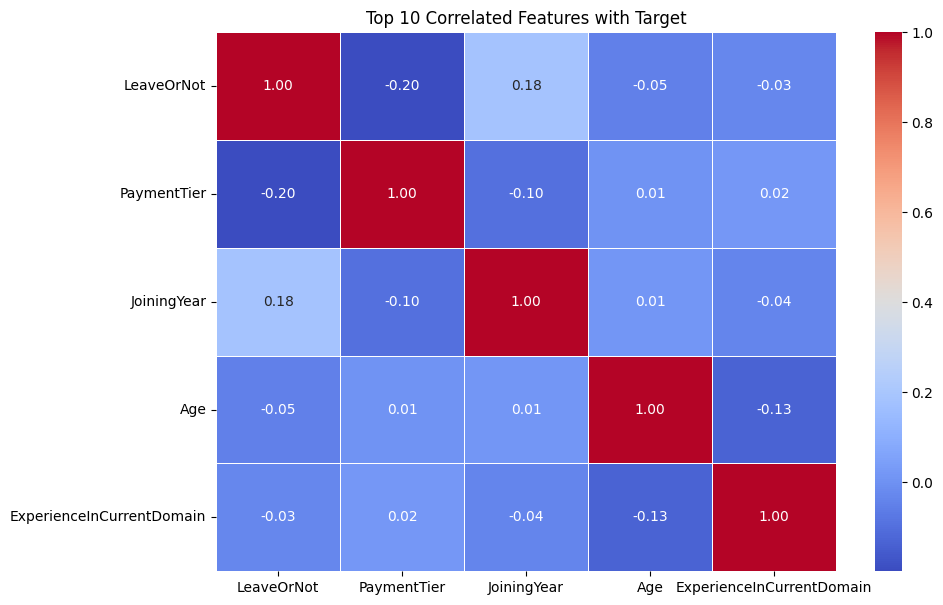

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    top_10_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Top 10 Correlated Features with Target")
plt.show()

In [13]:
X = data.drop('LeaveOrNot', axis=1)
y = data['LeaveOrNot']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [21]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Apply one-hot encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure columns are aligned after one-hot encoding (important for consistent feature sets)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for small datasets or L1/L2 regularization
model.fit(X_train_scaled, y_train)

# Predict probabilities on the scaled test set and assign to the correct rows in the original DataFrame
data.loc[X_test.index, 'Risk_Probability'] = model.predict_proba(X_test_scaled)[:, 1]

In [18]:
data['Risk_Category'] = pd.cut(
    data['Risk_Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
print(data[['Risk_Probability', 'Risk_Category']].head())

   Risk_Probability Risk_Category
0               NaN           NaN
1               NaN           NaN
2               NaN           NaN
3               NaN           NaN
4               NaN           NaN


In [19]:
coefficients = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                     Feature  Coefficient
4          Education_Masters     0.770748
7                  City_Pune     0.706232
9            EverBenched_Yes     0.571842
0                JoiningYear     0.351769
5              Education_PHD    -0.007420
2                        Age    -0.079121
3  ExperienceInCurrentDomain    -0.082813
1                PaymentTier    -0.181642
6             City_New Delhi    -0.516848
8                Gender_Male    -0.905602


The table shows how each feature influences the model’s prediction, where positive coefficients increase the likelihood of the outcome and negative ones decrease it. Factors like having a Master’s degree, being located in Pune, having been benched before, and more recent joining years positively impact the prediction, with education and location showing relatively strong effects. On the other hand, being male and being based in New Delhi significantly reduce the likelihood of the outcome, making them the strongest negative influences. Variables such as age, experience in the current domain, and payment tier have mild negative effects, while having a PhD has almost no impact. Overall, education level and city play a major role, while demographic and experience-related factors contribute more moderately, depending on their direction.
